In [20]:
"""

Robko 01 - ROS2 Control Software

Copyright (C) [2025] [Orlin Dimitrov]

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program.  If not, see <http://www.gnu.org/licenses/>.

"""

# https://github.com/robko01/robko01_ros2/blob/main/urdf/robko01.urdf
# https://www.geeksforgeeks.org/how-to-install-jupyter-notebook-in-linux/
# https://www.geeksforgeeks.org/using-matplotlib-with-jupyter-notebook/
# https://mymodelrobot.appspot.com/5629499534213120
# https://github.com/Phylliade/ikpy

import time
import os
import tempfile
import math
import numpy as np
from ikpy.chain import Chain
import ikpy.utils.plot as plot_utils
# import serial
import xacro

def compute(target_position, target_orientation):

    # Load XACRO model file.
    xacro_robot_model_path = os.path.join("description", "robko01.urdf.xacro")

    # Process xacro to URDF.
    robot_description = xacro.process_file(xacro_robot_model_path).toxml()

    # Write to temporary file.
    tmp_urdf = tempfile.NamedTemporaryFile(delete=False, suffix=".urdf")
    tmp_urdf.write(robot_description.encode("utf-8"))
    tmp_urdf.close()
    
    # urdf_robot_model_path = os.path.join("urdf", "robko01.urdf")

    # Load the kinematics description.
    kinematics_chain = Chain.from_urdf_file(
        tmp_urdf.name,
        active_links_mask=[False, True, True, True, True, True, False])
    
    # Inverst calculations.
    ik = kinematics_chain.inverse_kinematics(target_position, target_orientation, orientation_mode="Y")
    
    # Forward calculations.
    fk = kinematics_chain.forward_kinematics(ik)
    print(f"Computed position: {fk[:3, 3]}, original position : {target_position}")
    print("Computed position (readable) : %s" % [ "%.2f" % elem for elem in fk[:3, 3] ])
    
    # Plot the data.
    # %matplotlib widget
    #%matplotlib widget
    import matplotlib.pyplot as plt
    fig, ax = plot_utils.init_3d_figure()
    fig.set_figheight(9)  
    fig.set_figwidth(13)  
    kinematics_chain.plot(ik, ax, target=target_position)
    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.5, 0.5)
    ax.set_zlim(0, 0.6)
    plt.ion()

    return list(map(lambda r: math.degrees(r), ik.tolist()))

Computed position: [ 2.13024474e-01 -2.84354646e-05  3.80026203e-01], original position : [0.213, 0.0, 0.38]
Computed position (readable) : ['0.21', '-0.00', '0.38']
The angles of each joints are : [0.0, 9.363956800186491, 11.340518369898835, -4.177941350622293, -89.99609796746472, -7.652737291429329, 0.0]


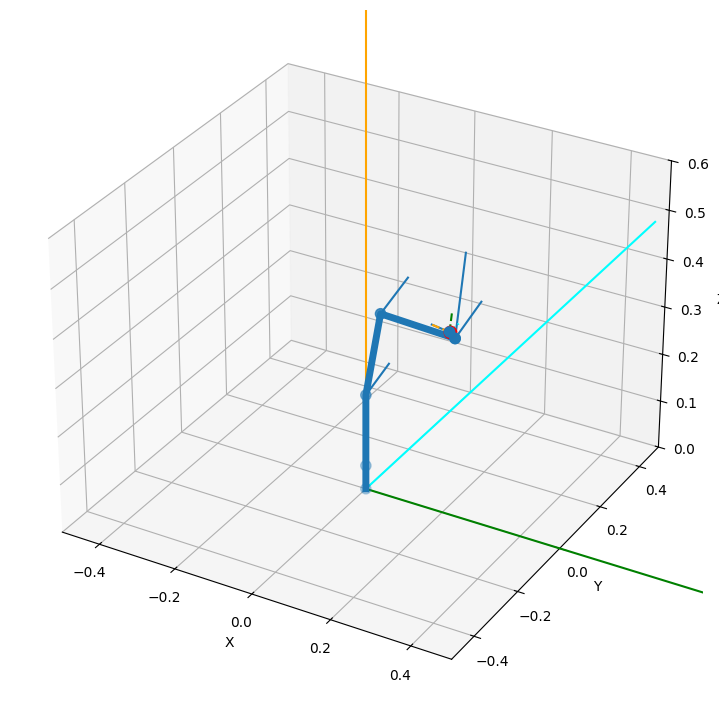

In [21]:
# target positions.
# target_position = [ 0.175, 0.0, 0.380]
# target_position = [ 0.220, 0.0, 0.380]
target_position = [ 0.213, 0.0, 0.380]
# target_position = [ 0.0, 0.0, 0.0]
target_orientation = [0, 0, 0]
robot_angles = compute(target_position, target_orientation)
print(f"The angles of each joints are : {robot_angles}")

In [22]:
angles = robot_angles[1:6]

# Conversion tables from radians to steps.
conversion_table_rad = [1125, 1125, 672, 241, 241]

# Conversion table from degreece to steps.
conversion_table_deg = [19.64, 19.64, 11.55, 4.27, 4.27]

def degrees_to_radians(degrees_list):
    return [math.radians(degree) for degree in degrees_list]

def radians_to_steps(radians_list):
    result = []
    for key, value in enumerate(radians_list):
        result.append(int(conversion_table_rad[key]*value))
    return result

def degrees_to_steps(degrees_list):
    result = []
    for key, value in enumerate(degrees_list):
        result.append(int(conversion_table_deg[key]*value))
    return result

radians = degrees_to_radians(angles)
steps_1   = radians_to_steps(radians)
steps_2   = degrees_to_steps(angles)

print(f"Deg: {angles}")
print(f"Steps: {steps_1}")
print(f"Rad: {radians}")
print(f"Steps: {steps_2}")

Deg: [9.363956800186491, 11.340518369898835, -4.177941350622293, -89.99609796746472, -7.652737291429329]
Steps: [183, 222, -49, -378, -32]
Rad: [0.16343187717776705, 0.19792938443763486, -0.07291883252357785, -1.570728223479636, -0.13356546252559462]
Steps: [183, 222, -48, -384, -32]


In [27]:
from robko01.communicators.serial.communicator import Communicator
'''
@STEP
232 - Speed
0 - Position of Base
0 - Position of Shoulder
0 - Position of Elbow
0 - Position of Left Diff
0 - Position of Right Diff
0 - Position of Gripper
'''
d = 232
q1 = steps_2[0]
q2 = steps_2[1]
q3 = steps_2[2]
q4 = steps_2[3]
q5 = steps_2[4]
q6 = int(0)
command = f"@STEP {d},{q1},{q2},{q3},{q4+q5},{q4-q5},{q6},0\r".encode('ASCII')
print(f"Command: {command}")
comm = Communicator("COM8", 9600)
comm.connect()
response = comm.send_frame(command)
print(response)
comm.disconnect()

Command: b'@STEP 232,39,48,-17,-416,-352,0,0\r'
b'@STEP 232,39,48,-17,-416,-352,0,0\r\r\r\nvoid enable_drivers(bool)\r\n\r\nResponse: \r\nOK\r\n\r\n'
